In [50]:
RUN_NAME = "densenet121_pretrained_20260223_182459"  # e.g. "densenet121_pretrained_20260222_220346"
FILTER_K = 14  # e.g. 10
FILTER_POS_RATE = 0.5  # e.g. 0.20
FILTER_NOISE = 0.5  # e.g. 0.30

# Func

In [51]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.offsetbox import AnchoredOffsetbox, HPacker, TextArea, VPacker
from PIL import Image, ImageDraw

plt.rcParams["figure.dpi"] = 300

OVERLAY_COLOR_MAP = {
    "white": (255, 255, 255),
    "blue": (0, 120, 255),
}
DEFAULT_LABEL_ORDER = [f"digit_{i}" for i in range(10)] + ["triangle", "square", "star", "heart", "circle"]


def parse_pipe_ints(s):
    if pd.isna(s):
        return []
    t = str(s).strip()
    if not t:
        return []
    return [int(x) for x in t.split("|") if x != ""]




In [52]:
# ---- Data paths & load ----
RESULTS_ROOT = Path("results_multilabel")
DATASET_ROOT = Path("../../datasets/mimic-cxr-clean/train")
CACHE_CSV = Path("cache/toy_pool_train_multilabel.csv")

# Optional controls:
# 1) RUN_NAME: set run folder name (or path). None = latest run by mtime.
# 2) FILTER_K: only keep rows with n_labels == FILTER_K.
# 3) FILTER_POS_RATE: only keep rows with pos_rate ~= FILTER_POS_RATE.
# 4) FILTER_NOISE: only keep rows with injected_noise_rate ~= FILTER_NOISE.
# RUN_NAME = "densenet121_pretrained_20260222_220346"  # e.g. "densenet121_pretrained_20260222_220346"
# FILTER_K = 3  # e.g. 10
# FILTER_POS_RATE = 0.3  # e.g. 0.20
# FILTER_NOISE = 0  # e.g. 0.30
POS_RATE_TOL = 1e-8
NOISE_TOL = 1e-8
DEFAULT_FILTER_SEED = 0  # default: use a single trial seed


def _resolve_run_dir(results_root, run_name):
    if run_name is None or str(run_name).strip() == "":
        cands = [
            q for q in results_root.glob("*")
            if q.is_dir() and (q / "cxr_toy_multilabel_sample_details.csv").exists()
        ]
        if not cands:
            raise FileNotFoundError(f"No valid run dir under: {results_root}")
        return sorted(cands, key=lambda q: q.stat().st_mtime, reverse=True)[0]

    run_name = str(run_name).strip()
    candidate = Path(run_name)
    run_dir = candidate if candidate.is_absolute() else (results_root / run_name)
    if not run_dir.is_dir():
        raise FileNotFoundError(f"RUN_NAME not found: {run_dir}")
    if not (run_dir / "cxr_toy_multilabel_sample_details.csv").exists():
        raise FileNotFoundError(
            f"Invalid run dir (missing sample csv): {run_dir}"
        )
    return run_dir


def _apply_k_pos_filter(df, k=None, pos_rate=None, noise=None, seed=0, pos_tol=1e-8, noise_tol=1e-8):
    if df is None or len(df) == 0:
        return df
    out = df.copy()
    if k is not None and "n_labels" in out.columns:
        out = out[pd.to_numeric(out["n_labels"], errors="coerce") == int(k)]
    if pos_rate is not None and "pos_rate" in out.columns:
        out = out[
            np.isclose(
                pd.to_numeric(out["pos_rate"], errors="coerce"),
                float(pos_rate),
                atol=float(pos_tol),
            )
        ]
    if noise is not None and "injected_noise_rate" in out.columns:
        out = out[
            np.isclose(
                pd.to_numeric(out["injected_noise_rate"], errors="coerce"),
                float(noise),
                atol=float(noise_tol),
            )
        ]
    if seed is not None and "seed" in out.columns:
        out = out[pd.to_numeric(out["seed"], errors="coerce") == int(seed)]
    return out.reset_index(drop=True)


RUN_DIR = _resolve_run_dir(RESULTS_ROOT, RUN_NAME)
print(f"Using RUN_DIR: {RUN_DIR}")
print(f"Filters: K={FILTER_K}, pos_rate={FILTER_POS_RATE}, noise={FILTER_NOISE}")

SAMPLE_CSV = RUN_DIR / "cxr_toy_multilabel_sample_details.csv"
ENTRY_CSV = RUN_DIR / "cxr_toy_multilabel_entry_details.csv"

sample_df_raw = pd.read_csv(SAMPLE_CSV)
entry_df_raw = pd.read_csv(ENTRY_CSV)
sample_df = _apply_k_pos_filter(
    sample_df_raw,
    k=FILTER_K,
    pos_rate=FILTER_POS_RATE,
    noise=FILTER_NOISE,
    seed=DEFAULT_FILTER_SEED,
    pos_tol=POS_RATE_TOL,
    noise_tol=NOISE_TOL,
)
entry_df = _apply_k_pos_filter(
    entry_df_raw,
    k=FILTER_K,
    pos_rate=FILTER_POS_RATE,
    noise=FILTER_NOISE,
    seed=DEFAULT_FILTER_SEED,
    pos_tol=POS_RATE_TOL,
    noise_tol=NOISE_TOL,
)

cache_df = pd.read_csv(CACHE_CSV)
cache_by_id = cache_df.set_index("pool_row_id", drop=False) if "pool_row_id" in cache_df.columns else None

cache_label_cols = [c for c in cache_df.columns if c.endswith("_label")]
cache_label_names = [c[:-6] for c in cache_label_cols]
LABEL_NAMES = [x for x in DEFAULT_LABEL_ORDER if x in cache_label_names] + [
    x for x in cache_label_names if x not in DEFAULT_LABEL_ORDER
]

print("sample_df(raw -> filtered):", sample_df_raw.shape, "->", sample_df.shape)
print("entry_df (raw -> filtered):", entry_df_raw.shape, "->", entry_df.shape)
print("labels:", len(LABEL_NAMES), LABEL_NAMES)



Using RUN_DIR: results_multilabel\densenet121_pretrained_20260223_182459
Filters: K=14, pos_rate=0.5, noise=0.5
sample_df(raw -> filtered): (432000, 22) -> (12000, 22)
entry_df (raw -> filtered): (4608000, 17) -> (168000, 17)
labels: 14 ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9', 'triangle', 'square', 'star', 'heart']


In [53]:
# ---- Render helpers ----
DIGIT_SEGMENTS = {
    0: ("a", "b", "c", "d", "e", "f"),
    1: ("b", "c"),
    2: ("a", "b", "g", "e", "d"),
    3: ("a", "b", "g", "c", "d"),
    4: ("f", "g", "b", "c"),
    5: ("a", "f", "g", "c", "d"),
    6: ("a", "f", "g", "e", "c", "d"),
    7: ("a", "b", "c"),
    8: ("a", "b", "c", "d", "e", "f", "g"),
    9: ("a", "b", "c", "d", "f", "g"),
}


def _draw_star(draw, x, y, r, color):
    pts = []
    outer = r
    inner = max(3, int(r * 0.45))
    for i in range(10):
        ang = -np.pi / 2 + i * np.pi / 5
        rr = outer if (i % 2 == 0) else inner
        pts.append((int(x + rr * np.cos(ang)), int(y + rr * np.sin(ang))))
    draw.polygon(pts, fill=color)


def _draw_heart(draw, x, y, r, color):
    top_r = max(3, int(r * 0.55))
    offset = int(r * 0.45)
    draw.ellipse((x - offset - top_r, y - top_r, x - offset + top_r, y + top_r), fill=color)
    draw.ellipse((x + offset - top_r, y - top_r, x + offset + top_r, y + top_r), fill=color)
    tip_y = y + int(r * 1.20)
    pts = [
        (x - int(r * 1.35), y + int(r * 0.15)),
        (x + int(r * 1.35), y + int(r * 0.15)),
        (x, tip_y),
    ]
    draw.polygon(pts, fill=color)


def _draw_digit(draw, x, y, r, digit, color):
    segs = DIGIT_SEGMENTS.get(int(digit), ())
    if not segs:
        return
    half_w = max(3, int(r * 0.85))
    half_h = max(5, int(r * 1.35))
    thick = max(2, int(r * 0.30))
    t2 = thick // 2
    boxes = {
        "a": (x - half_w, y - half_h - t2, x + half_w, y - half_h + t2),
        "g": (x - half_w, y - t2, x + half_w, y + t2),
        "d": (x - half_w, y + half_h - t2, x + half_w, y + half_h + t2),
        "f": (x - half_w - t2, y - half_h, x - half_w + t2, y),
        "b": (x + half_w - t2, y - half_h, x + half_w + t2, y),
        "e": (x - half_w - t2, y, x - half_w + t2, y + half_h),
        "c": (x + half_w - t2, y, x + half_w + t2, y + half_h),
    }
    for s in segs:
        draw.rectangle(boxes[s], fill=color)


def _draw_overlay_label(draw, label_name, x, y, r, color):
    if label_name.startswith("digit_"):
        _draw_digit(draw, x=x, y=y, r=r, digit=int(label_name.split("_")[1]), color=color)
        return
    if label_name == "triangle":
        draw.polygon([(x, y - r), (x - r, y + r), (x + r, y + r)], fill=color)
        return
    if label_name == "square":
        draw.rectangle((x - r, y - r, x + r, y + r), fill=color)
        return
    if label_name == "star":
        _draw_star(draw, x=x, y=y, r=r, color=color)
        return
    if label_name == "heart":
        _draw_heart(draw, x=x, y=y, r=r, color=color)
        return
    if label_name == "circle":
        draw.ellipse((x - r, y - r, x + r, y + r), fill=color)


def render_sample(row, image_size=224, overlay_color="white"):
    img_path = DATASET_ROOT / row["image_path"]
    img = Image.open(img_path).convert("RGB").resize((image_size, image_size))
    color = OVERLAY_COLOR_MAP[overlay_color]

    if cache_by_id is None:
        return img

    pool_id = int(row["pool_row_id"])
    if pool_id not in cache_by_id.index:
        return img

    meta = cache_by_id.loc[pool_id]
    if isinstance(meta, pd.DataFrame):
        meta = meta.iloc[0]

    labels = parse_pipe_ints(row["clean_labels"])
    n_labels = int(row["n_labels"])
    names = LABEL_NAMES[:n_labels]

    draw = ImageDraw.Draw(img)
    w, h = img.size
    for j, name in enumerate(names):
        if j >= len(labels) or labels[j] != 1:
            continue
        x_key, y_key, r_key = f"{name}_x_frac", f"{name}_y_frac", f"{name}_r_frac"
        if x_key not in meta.index or y_key not in meta.index or r_key not in meta.index:
            continue

        x = int(float(meta[x_key]) * w)
        y = int(float(meta[y_key]) * h)
        r = int(float(meta[r_key]) * min(w, h))
        r = max(5, min(r, min(w, h) // 6))
        pad = int(r * 1.5)
        x = max(pad, min(x, w - pad))
        y = max(pad, min(y, h - pad))
        _draw_overlay_label(draw, label_name=name, x=x, y=y, r=r, color=color)

    return img



In [54]:
# ---- Entry-level estimation grid ----
ENTRY_ORDER = ["TP", "FP", "FN", "TN", "UNK"]
ENTRY_COLORS = {"TP": "#2ca02c", "FP": "#d62728", "FN": "#ff7f0e", "TN": "#1f77b4", "UNK": "#1f77b4"}
ENTRY_DESC = {
    "TP": "flipped and detected",
    "FP": "not flipped but flagged",
    "FN": "flipped but missed",
    "TN": "not flipped and not flagged",
}
SAMPLE_KEYS = ["pos_rate", "n_labels", "seed", "injected_noise_rate", "sample_local_index"]
ENTRY_CACHE = {}


def _int(v, d=None):
    try:
        if pd.isna(v):
            return d
        return int(v)
    except Exception:
        return d


def _flt(v, d=np.nan):
    try:
        if pd.isna(v):
            return d
        return float(v)
    except Exception:
        return d


def _parse_pipe_floats(s):
    if pd.isna(s):
        return []
    t = str(s).strip()
    if not t:
        return []
    out = []
    for x in t.split("|"):
        if x == "":
            continue
        try:
            out.append(float(x))
        except Exception:
            out.append(np.nan)
    return out


def _fmt_ratio(num, den):
    n = _int(num, None)
    d = _int(den, None)
    if n is None or d is None or d <= 0:
        return "NA"
    return f"{n}/{d}={float(n)/float(d):.2f}"


def _entry_case(true_flip, est_issue):
    t = _int(true_flip, None)
    e = _int(est_issue, None)
    if t is None or e is None:
        return "UNK"
    if t == 1 and e == 1:
        return "TP"
    if t == 0 and e == 1:
        return "FP"
    if t == 1 and e == 0:
        return "FN"
    return "TN"


def _row_key(row):
    out = []
    for k in SAMPLE_KEYS:
        v = row.get(k, None)
        if k in ("pos_rate", "injected_noise_rate"):
            try:
                out.append(round(float(v), 8))
            except Exception:
                out.append(None)
        else:
            out.append(_int(v, None))
    return tuple(out)


def _fetch_entry_rows(row):
    try:
        cond = (
            np.isclose(entry_df["pos_rate"].astype(float).to_numpy(), float(row["pos_rate"]), atol=1e-8)
            & (entry_df["n_labels"].astype(int).to_numpy() == int(row["n_labels"]))
            & (entry_df["seed"].astype(int).to_numpy() == int(row["seed"]))
            & np.isclose(entry_df["injected_noise_rate"].astype(float).to_numpy(), float(row["injected_noise_rate"]), atol=1e-8)
            & (entry_df["sample_local_index"].astype(int).to_numpy() == int(row["sample_local_index"]))
        )
        sub = entry_df[cond]
        if len(sub) == 0:
            return None
        return sub.sort_values("label_index").reset_index(drop=True)
    except Exception:
        return None


def _entry_records(row):
    key = _row_key(row)
    if key in ENTRY_CACHE:
        return ENTRY_CACHE[key]

    recs = []
    sub = _fetch_entry_rows(row)
    if sub is not None:
        for _, r in sub.iterrows():
            recs.append(
                {
                    "label_index": _int(r.get("label_index", None), None),
                    "label_name": str(r.get("label_name", "?")),
                    "pred_prob": _flt(r.get("pred_prob", np.nan), np.nan),
                    "case": _entry_case(r.get("true_flip_entry", None), r.get("est_issue_entry", None)),
                }
            )
    else:
        flips = parse_pipe_ints(row.get("flip_entry_mask", np.nan))
        issues = parse_pipe_ints(row.get("issue_entry_mask", np.nan))
        probs = _parse_pipe_floats(row.get("pred_probs", np.nan))
        k = _int(row.get("n_labels", 0), 0) or 0
        names = LABEL_NAMES[:k]
        n = max(len(names), len(flips), len(issues), len(probs))
        for i in range(n):
            t = flips[i] if i < len(flips) else None
            e = issues[i] if i < len(issues) else None
            p = probs[i] if i < len(probs) else np.nan
            recs.append(
                {
                    "label_index": i,
                    "label_name": names[i] if i < len(names) else f"label_{i}",
                    "pred_prob": _flt(p, np.nan),
                    "case": _entry_case(t, e),
                }
            )

    ENTRY_CACHE[key] = recs
    return recs


def _entry_counts(row):
    cnt = {c: 0 for c in ENTRY_ORDER}
    for r in _entry_records(row):
        c = r.get("case", "UNK")
        cnt[c] = cnt.get(c, 0) + 1
    return cnt


def _entry_score(row):
    cnt = _entry_counts(row)
    mismatch = int(cnt.get("FP", 0) + cnt.get("FN", 0))
    q = _flt(row.get("sample_quality_self_confidence", np.nan), np.nan)
    bonus = (1.0 - q) * 0.01 if not np.isnan(q) else 0.0
    return float(mismatch) + float(bonus)


def _select_with_coverage(df, n_show=12, required=("TP", "FP", "FN", "TN")):
    base = df.reset_index(drop=True).copy()
    n = min(int(n_show), len(base))
    if n <= 0:
        return base.head(0)

    selected = []
    used = set()
    for target in required:
        best_idx, best_score = None, None
        for i in range(len(base)):
            if i in used:
                continue
            cases = {r.get("case", "UNK") for r in _entry_records(base.iloc[i])}
            if target not in cases:
                continue
            score = _entry_score(base.iloc[i])
            if best_idx is None or score > best_score:
                best_idx, best_score = i, score
        if best_idx is not None:
            selected.append(best_idx)
            used.add(best_idx)
            if len(selected) >= n:
                break

    if len(selected) < n:
        remain = [i for i in range(len(base)) if i not in used]
        remain = sorted(remain, key=lambda i: _entry_score(base.iloc[i]), reverse=True)
        selected.extend(remain[: (n - len(selected))])

    return base.iloc[selected].reset_index(drop=True)


def _short_name(name):
    s = str(name)
    if s.startswith("digit_"):
        return "d" + s.split("_", 1)[1]
    mp = {"triangle": "tri", "square": "sq", "star": "star", "heart": "heart", "circle": "cir"}
    return mp.get(s, s[:4])


def _pair_label_name(name):
    s = str(name)
    if s.startswith("digit_"):
        return s.split("_", 1)[1]
    return s


def _pair_text(g, t):
    g_txt = "NA" if g is None else str(g)
    t_txt = "NA" if t is None else str(t)
    return f"{g_txt}|{t_txt}", (g_txt != "NA" and t_txt != "NA" and g_txt != t_txt)


def _add_header_block(ax, meta_line, label_names, gt_vals, train_vals, per_line=4):
    items = []
    for i, name in enumerate(label_names):
        g = gt_vals[i] if i < len(gt_vals) else None
        t = train_vals[i] if i < len(train_vals) else None
        pair_txt, is_flip = _pair_text(g, t)
        items.append((f"'{_pair_label_name(name)}':{pair_txt}", is_flip))

    if not items:
        items = [("NA", False)]

    lines = []
    for s in range(0, len(items), per_line):
        chunk = items[s:s + per_line]
        cells = [
            TextArea(
                txt,
                textprops=dict(
                    color=("#8e44ad" if is_flip else "#222222"),
                    fontsize=6.5,
                    family="DejaVu Sans Mono",
                ),
            )
            for txt, is_flip in chunk
        ]
        lines.append(HPacker(children=cells, align="center", pad=0, sep=7))

    meta_lines = [m for m in str(meta_line).split("\n") if str(m).strip() != ""]
    if not meta_lines:
        meta_lines = ["NA"]
    meta_boxes = [
        TextArea(m, textprops=dict(color="#111111", fontsize=7.0, weight="bold"))
        for m in meta_lines
    ]
    explain_lines = [
        TextArea("TP: true_flip_entry = 1 and est_issue_entry = 1 (flipped and detected).", textprops=dict(color="#2ca02c", fontsize=6.0)),
        TextArea("FP: true_flip_entry = 0 and est_issue_entry = 1 (not flipped but flagged).", textprops=dict(color="#d62728", fontsize=6.0)),
        TextArea("FN: true_flip_entry = 1 and est_issue_entry = 0 (flipped but missed).", textprops=dict(color="#ff7f0e", fontsize=6.0)),
        TextArea("TN: true_flip_entry = 0 and est_issue_entry = 0 (not flipped and not flagged).", textprops=dict(color="#1f77b4", fontsize=6.0)),
    ]
    header = TextArea("GT|Train (purple = flipped)", textprops=dict(color="#333333", fontsize=6.5, weight="bold"))
    vbox = VPacker(children=meta_boxes + explain_lines + [header] + lines, align="left", pad=0, sep=1)
    anchored = AnchoredOffsetbox(
        loc="lower left",
        child=vbox,
        pad=0,
        frameon=False,
        bbox_to_anchor=(0.0, 1.01),
        bbox_transform=ax.transAxes,
        borderpad=0,
    )
    ax.add_artist(anchored)


def _label_geometry(row, label_name, image_size=224):
    if cache_by_id is None:
        return None
    pool_id = _int(row.get("pool_row_id", None), None)
    if pool_id is None or pool_id not in cache_by_id.index:
        return None

    meta = cache_by_id.loc[pool_id]
    if isinstance(meta, pd.DataFrame):
        meta = meta.iloc[0]

    x_key, y_key, r_key = f"{label_name}_x_frac", f"{label_name}_y_frac", f"{label_name}_r_frac"
    if x_key not in meta.index or y_key not in meta.index or r_key not in meta.index:
        return None

    w = h = int(image_size)
    x = int(float(meta[x_key]) * w)
    y = int(float(meta[y_key]) * h)
    r = int(float(meta[r_key]) * min(w, h))
    r = max(5, min(r, min(w, h) // 6))
    pad = int(r * 1.5)
    x = max(pad, min(x, w - pad))
    y = max(pad, min(y, h - pad))
    return {"x": x, "y": y, "r": r, "x0": x - r, "y0": y - r, "w": 2 * r, "h": 2 * r}


def _draw_case_boxes(ax, row, image_size=224):
    recs = _entry_records(row)
    for r in recs:
        label_name = r.get("label_name", "")
        case = r.get("case", "UNK")
        geom = _label_geometry(row, label_name, image_size=image_size)
        if geom is None:
            continue

        color = ENTRY_COLORS.get(case, ENTRY_COLORS["UNK"])
        linestyle = "-"
        lw = 2.2
        alpha = 0.95

        ax.add_patch(
            Rectangle(
                (geom["x0"], geom["y0"]),
                geom["w"],
                geom["h"],
                fill=False,
                edgecolor=color,
                linewidth=lw,
                linestyle=linestyle,
                alpha=alpha,
            )
        )

        # Keep text on boxes only for non-TN to reduce clutter.
        if case in ("TP", "FP", "FN", "TN"):
            pred_prob = _flt(r.get("pred_prob", np.nan), np.nan)
            prob_txt = "NA" if np.isnan(pred_prob) else f"{pred_prob:.2f}"
            ax.text(
                geom["x0"],
                max(2, geom["y0"] - 2),
                f"{_short_name(label_name)}({prob_txt}):{case}",
                fontsize=6,
                color="white",
                ha="left",
                va="bottom",
                bbox=dict(boxstyle="round,pad=0.15", facecolor=color, edgecolor=color, alpha=0.85),
            )


def show_grid_entry_estimation(df, n_show=12, n_cols=4, image_size=224, overlay_color="white", ensure_case_coverage=True, required_cases=("TP", "FP", "FN", "TN"), show_legend=True, save_svg_path=None):
    if df is None or len(df) == 0:
        print("No samples to show.")
        return

    view_df = _select_with_coverage(df, n_show=n_show, required=required_cases) if ensure_case_coverage else df.reset_index(drop=True).head(min(int(n_show), len(df))).copy()
    n = len(view_df)
    if n <= 0:
        print("No samples to show.")
        return

    present = set()
    for i in range(n):
        recs = _entry_records(view_df.iloc[i])
        present |= {r.get("case", "UNK") for r in recs}
    missing = [c for c in required_cases if c not in present]
    print(f"Coverage in shown grid: present={sorted([c for c in present if c != 'UNK'])}, missing={missing}")

    # Global case counts across the full input df (not per-sample).
    global_cnt = {c: 0 for c in ENTRY_ORDER}
    for j in range(len(df)):
        c = _entry_counts(df.iloc[j])
        for k_case in ENTRY_ORDER:
            global_cnt[k_case] += int(c.get(k_case, 0))
    gtp = int(global_cnt.get("TP", 0))
    gfp = int(global_cnt.get("FP", 0))
    gfn = int(global_cnt.get("FN", 0))
    gtn = int(global_cnt.get("TN", 0))
    print(f"Global TP/FP/FN/TN over input df: {gtp}/{gfp}/{gfn}/{gtn}")

    n_cols = min(int(n_cols), n)
    n_rows = int(math.ceil(n / float(n_cols)))
    row_h = 7.4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6.1 * n_cols, row_h * n_rows))
    axes = np.array(axes).reshape(-1)

    for i in range(n_rows * n_cols):
        ax = axes[i]
        if i >= n:
            ax.axis("off")
            continue

        row = view_df.iloc[i]
        ax.imshow(np.asarray(render_sample(row, image_size=image_size, overlay_color=overlay_color)))
        ax.axis("off")

        # Draw entry-level colored boxes wherever geometry exists.
        _draw_case_boxes(ax, row, image_size=image_size)

        cnt = _entry_counts(row)
        tp, fp, fn, tn, unk = cnt.get("TP", 0), cnt.get("FP", 0), cnt.get("FN", 0), cnt.get("TN", 0), cnt.get("UNK", 0)
        pool_id = _int(row.get("pool_row_id", None), None)
        k = _int(row.get("n_labels", None), None)
        seed = _int(row.get("seed", None), None)
        try:
            pos_pct_txt = f"{100.0 * float(row.get('pos_rate', np.nan)):.2f}%"
        except Exception:
            pos_pct_txt = "NA"
        try:
            noise_pct_txt = f"{100.0 * float(row.get('injected_noise_rate', np.nan)):.2f}%"
        except Exception:
            noise_pct_txt = "NA"

        denom = int(gtp + gfp + gfn + gtn)
        est_pct_txt = f"{100.0 * float(gtp + gfp) / float(denom):.2f}%" if denom > 0 else "NA"

        label_names = LABEL_NAMES[:k] if isinstance(k, int) and k is not None else LABEL_NAMES
        gt_vals = parse_pipe_ints(row.get("clean_labels", np.nan))
        train_vals = parse_pipe_ints(row.get("noisy_labels", np.nan))

        meta = (
            f"id={pool_id}, K={k}\n"
            f"pos_rate={pos_pct_txt}, injected_noise={noise_pct_txt}, estimate_noise (TP+FP)/total={est_pct_txt}\n"
            f"GLOBAL TP/FP/FN/TN={gtp}/{gfp}/{gfn}/{gtn}"
        )
        _add_header_block(ax, meta, label_names, gt_vals, train_vals, per_line=4)

        edge_case = "TN"
        if fp > 0 or fn > 0:
            edge_case = "FP" if fp >= fn else "FN"
        elif tp > 0:
            edge_case = "TP"
        edge_color = ENTRY_COLORS.get(edge_case, ENTRY_COLORS["UNK"])
        for s in ax.spines.values():
            s.set_visible(True)
            s.set_linewidth(2.8)
            s.set_edgecolor(edge_color)

        # Keep bottom tags as fallback for entries without drawable geometry.

    if show_legend:
        legend = " | ".join([f"{k}: {ENTRY_DESC[k]}" for k in ["TP", "FP", "FN", "TN"]])
        fig.text(0.01, 0.01, legend, ha="left", va="bottom", fontsize=9)

    plt.tight_layout(h_pad=2.4)

    if save_svg_path is not None:
        svg_path = Path(save_svg_path)
        svg_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(svg_path, format="svg", bbox_inches="tight")
        print(f"[saved svg] {svg_path}")

    plt.show()








# Plot

Active filters in plotting: K=14, pos_rate=0.5, noise=0.5

Mixed pool from sample_details: n=12000
Coverage in shown grid: present=['FN', 'FP', 'TN', 'TP'], missing=[]
Global TP/FP/FN/TN over input df: 34285/33891/49715/50109
[saved svg] results_multilabel\densenet121_pretrained_20260223_182459\inspection_plots_svg\mixed_grid_k14_pos0p5_noise0p5.svg


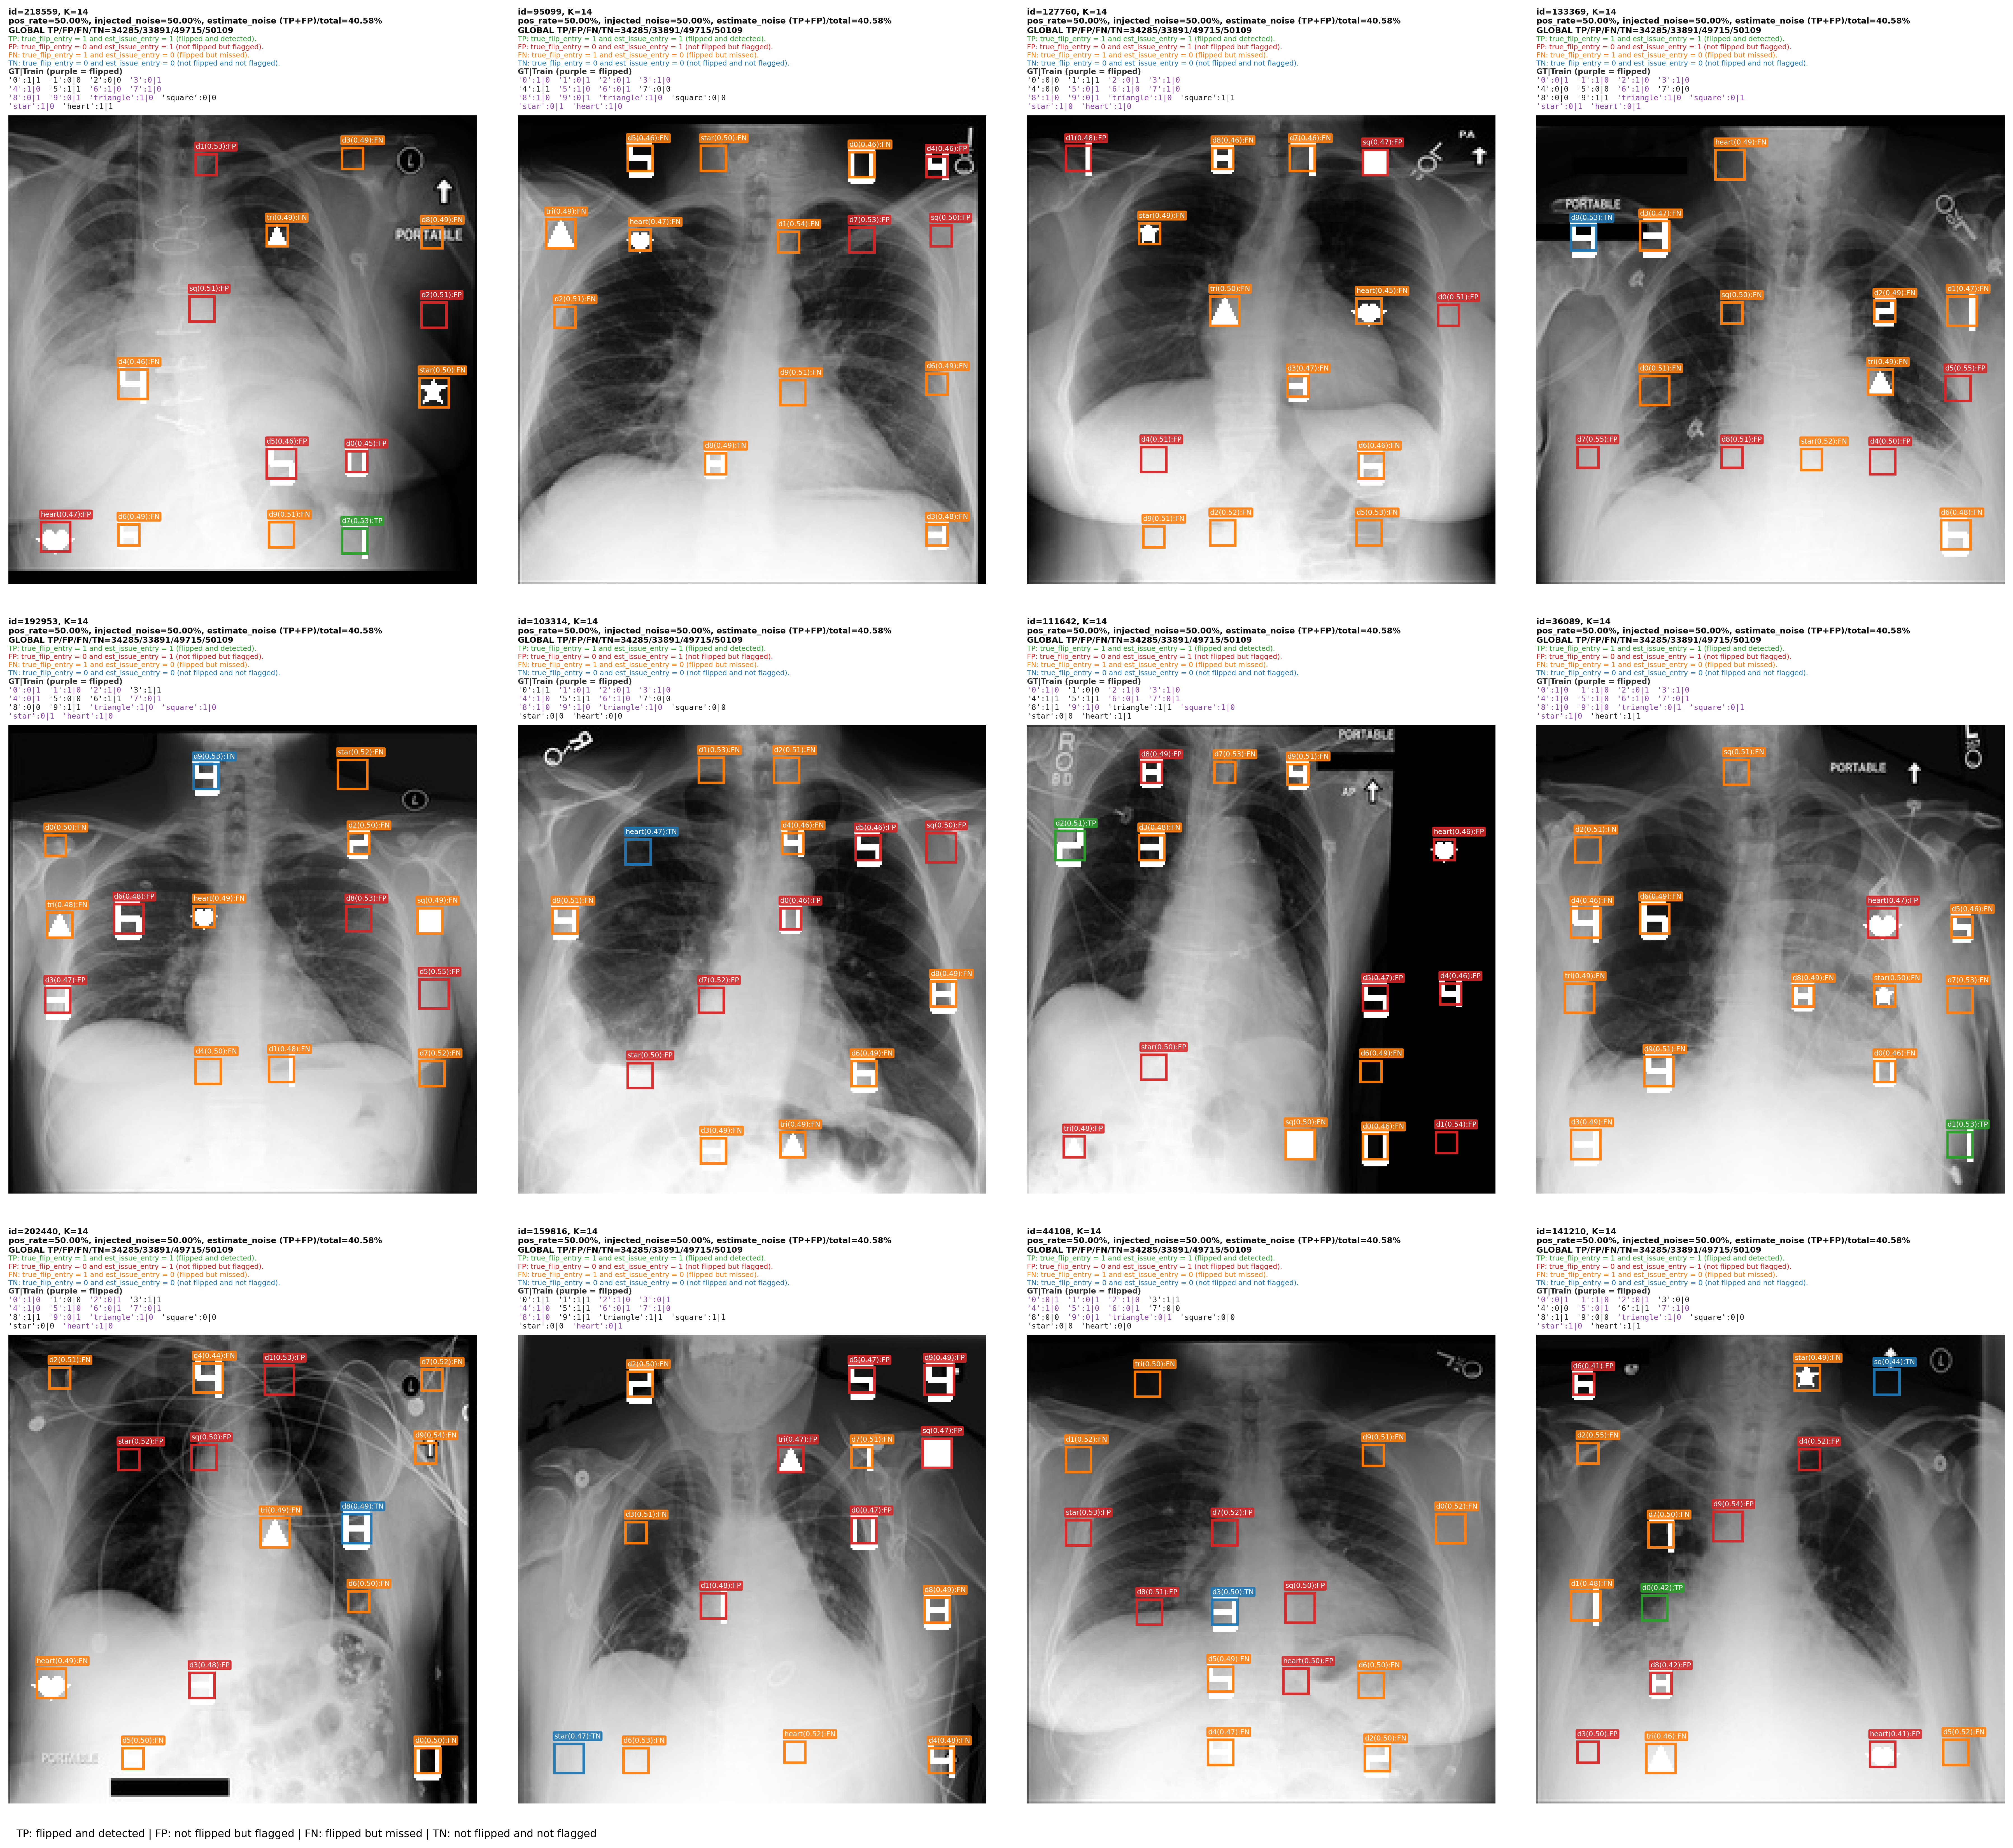

In [55]:
# ---- One mixed grid + one top-mismatch-label grid (from source result CSVs) ----
SHOW_N = 12
SHOW_COLS = 4
SHOW_N_TOP_LABEL = 12
OVERLAY_COLOR = "white"
SAVE_SVG = True
SVG_OUT_DIR = RUN_DIR / "inspection_plots_svg"


def _fmt_filter_token(v):
    if v is None:
        return "all"
    return str(v).replace(".", "p")

SVG_MIXED_PATH = SVG_OUT_DIR / (
    f"mixed_grid_k{_fmt_filter_token(FILTER_K)}_"
    f"pos{_fmt_filter_token(FILTER_POS_RATE)}_"
    f"noise{_fmt_filter_token(FILTER_NOISE)}.svg"
)


def _ensure_render_cols(df):
    if df is None or len(df) == 0:
        return df
    need = ["pool_row_id", "image_path", "clean_labels", "noisy_labels", "sample_quality_self_confidence"]
    out = df.copy()
    miss = [c for c in need if c not in out.columns]
    if miss:
        src_cols = [c for c in (SAMPLE_KEYS + miss) if c in sample_df.columns]
        if all(k in src_cols for k in SAMPLE_KEYS):
            out = out.merge(sample_df[src_cols].drop_duplicates(SAMPLE_KEYS), on=SAMPLE_KEYS, how="left")
    return out


def _dedup_by_sample(df):
    if df is None or len(df) == 0:
        return df
    out = df.copy()
    if all(k in out.columns for k in SAMPLE_KEYS):
        score = pd.Series(0.0, index=out.index)
        if "entry_mismatch_count" in out.columns:
            score = score + out["entry_mismatch_count"].fillna(0).astype(float)
        if "sample_quality_self_confidence" in out.columns:
            score = score + (1.0 - out["sample_quality_self_confidence"].fillna(1.0).astype(float)) * 0.01
        if "est_issue_sample" in out.columns:
            score = score + out["est_issue_sample"].fillna(0).astype(float) * 0.1
        out["_score"] = score
        out = out.sort_values("_score", ascending=False)
        out = out.drop_duplicates(SAMPLE_KEYS, keep="first").reset_index(drop=True)
        out = out.drop(columns=["_score"], errors="ignore")
    return out


print(f"Active filters in plotting: K={FILTER_K}, pos_rate={FILTER_POS_RATE}, noise={FILTER_NOISE}")

# A) Mixed bucket grid: use filtered sample details directly.
mixed_df = _ensure_render_cols(sample_df.copy())
mixed_df = _dedup_by_sample(mixed_df)

if mixed_df is None or len(mixed_df) == 0:
    raise RuntimeError(
        f"No samples left after filter. K={FILTER_K}, pos_rate={FILTER_POS_RATE}, noise={FILTER_NOISE}"
    )

print("")
print(f"Mixed pool from sample_details: n={len(mixed_df)}")
show_grid_entry_estimation(
    mixed_df,
    n_show=min(SHOW_N, len(mixed_df)),
    n_cols=SHOW_COLS,
    image_size=224,
    overlay_color=OVERLAY_COLOR,
    ensure_case_coverage=True,
    required_cases=("TP", "FP", "FN", "TN"),
    show_legend=True,
    save_svg_path=SVG_MIXED_PATH if SAVE_SVG else None,
)


# # B) Top mismatch label grid: compute from filtered entry details directly.
# if entry_df is None or len(entry_df) == 0:
#     print("")
#     print("No entry rows after filter; skip top-label grid.")
# else:
#     e = entry_df.copy()
#     if ("true_flip_entry" not in e.columns) or ("est_issue_entry" not in e.columns):
#         print("")
#         print("Missing true_flip_entry/est_issue_entry in entry_details; skip top-label grid.")
#     else:
#         t = pd.to_numeric(e["true_flip_entry"], errors="coerce")
#         p = pd.to_numeric(e["est_issue_entry"], errors="coerce")
#         e["entry_mismatch"] = (t != p).astype(int)

#         stats = (
#             e.groupby("label_name", as_index=False)
#             .agg(
#                 n=("label_name", "size"),
#                 mismatch_count=("entry_mismatch", "sum"),
#                 mismatch_rate=("entry_mismatch", "mean"),
#                 true_flip_rate=("true_flip_entry", "mean"),
#                 est_issue_rate=("est_issue_entry", "mean"),
#             )
#             .sort_values(["mismatch_rate", "mismatch_count"], ascending=[False, False])
#             .reset_index(drop=True)
#         )

#         if len(stats) == 0:
#             print("")
#             print("No label stats after grouping; skip top-label grid.")
#         else:
#             top_row = stats.iloc[0]
#             top_label = str(top_row["label_name"])
#             print("")
#             print(
#                 f"Top mismatch label (from entry_details): {top_label} | "
#                 f"mismatch_rate={float(top_row['mismatch_rate']):.4f}, "
#                 f"count={int(top_row['mismatch_count'])}/{int(top_row['n'])}"
#             )

#             top_label_df = e[e["label_name"].astype(str) == top_label].copy().reset_index(drop=True)
#             if "entry_quality_self_confidence" in top_label_df.columns:
#                 top_label_df["_sort_uncertain"] = 1.0 - pd.to_numeric(
#                     top_label_df["entry_quality_self_confidence"], errors="coerce"
#                 ).fillna(1.0)
#             else:
#                 top_label_df["_sort_uncertain"] = 0.0
#             top_label_df = top_label_df.sort_values(
#                 ["entry_mismatch", "_sort_uncertain"], ascending=[False, False]
#             ).drop(columns=["_sort_uncertain"], errors="ignore")

#             top_label_df = _ensure_render_cols(top_label_df)
#             top_label_df = _dedup_by_sample(top_label_df)

#             print(f"Top-label pool after dedup: n={len(top_label_df)}")
#             show_grid_entry_estimation(
#                 top_label_df,
#                 n_show=min(SHOW_N_TOP_LABEL, len(top_label_df)),
#                 n_cols=SHOW_COLS,
#                 image_size=224,
#                 overlay_color=OVERLAY_COLOR,
#                 ensure_case_coverage=True,
#                 required_cases=("TP", "FP", "FN", "TN"),
#                 show_legend=True,
#             )

